# Deep Learning

In [5]:
# clone the repo that contains the data
!git clone https://github.com/alexeygrigorev/clothing-dataset-small.git data
!rm -rf data/.git*

Cloning into 'data'...
remote: Enumerating objects: 3839, done.
remote: Counting objects: 100% (400/400), done.
remote: Compressing objects: 100% (400/400), done.
Receiving objects:   5% (192/3839), 4.08 MiB | 1.56 MiB/sReceiving objects:   6% (231/3839), 6.67 MiB | 2.14 MiB/sReceiving objects:   8% (308/3839), 8.79 MiB | 2.41 MiB/sReceiving objects:  10% (384/3839), 8.79 MiB | 2.41 MiB/sReceiving objects:  11% (423/3839), 8.79 MiB | 2.41 MiB/sReceiving objects:  13% (500/3839), 11.71 MiB | 2.81 MiB/sReceiving objects:  15% (576/3839), 13.91 MiB | 2.97 MiB/sReceiving objects:  17% (653/3839), 17.18 MiB | 3.65 MiB/sReceiving objects:  19% (730/3839), 17.18 MiB | 3.65 MiB/sReceiving objects:  21% (807/3839), 19.82 MiB | 4.18 MiB/sReceiving objects:  22% (849/3839), 19.82 MiB | 4.18 MiB/sReceiving objects:  24% (922/3839), 23.37 MiB | 4.83 MiB/sReceiving objects:  26% (999/3839), 26.17 MiB | 5.12 MiB/sReceiving objects:  28% (1075/3839), 26.17 MiB | 5.12 MiB/sReceiving objects:  29% (1114

In [7]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Pretrained Convolutional Neural Networks

In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.applications.xception import Xception, preprocess_input, decode_predictions

In [20]:
# load a single image
path = './data/train/t-shirt'
name = '5f0a3fa0-6a3d-4b68-b213-72766a643de7.jpg'
full_path = f'{path}/{name}'
img = load_img(full_path, target_size=(299, 299))

In [21]:
x = np.array(img)

In [22]:
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

In [26]:
X = np.array([x])
X = preprocess_input(X)

In [30]:
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step


In [31]:
preds.shape

(1, 1000)

In [36]:
decode_predictions(preds)

[[('n03595614', 'jersey', 0.6819634),
  ('n02916936', 'bulletproof_vest', 0.038139984),
  ('n04370456', 'sweatshirt', 0.03432479),
  ('n03710637', 'maillot', 0.0113542145),
  ('n04525038', 'velvet', 0.0018453592)]]

### Transfer learning

In [58]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import GlobalAvgPool2D, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

In [39]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

In [40]:
train_ds = train_gen.flow_from_directory('./data/train', target_size=(150, 150), batch_size=32)
val_ds = val_gen.flow_from_directory('./data/validation', target_size=(150, 150), batch_size=32, shuffle=False)

Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.


In [50]:
# create model with convolutional layers only
base_model = Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)

base_model.trainable = False

In [54]:
inputs = keras.Input(shape=(150, 150, 3))
base = base_model(inputs, training=False)
vectors = GlobalAvgPool2D()(base) # convert feature maps to one dimension
outputs = Dense(10)(vectors)
model = keras.Model(inputs, outputs)

In [60]:
# train the model
learning_rate = .01
optimizer = Adam(learning_rate=learning_rate)
loss = CategoricalCrossentropy(from_logits=True) # keep the raw scores (no activation)

In [62]:
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy'])

In [63]:
history = model.fit(train_ds, epochs=10, validation_data=val_ds)

/Users/bastienwinant/Desktop/projects/ml-zoomcamp/.venv/lib/python3.9/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.5471 - loss: 1.8248 - val_accuracy: 0.7654 - val_loss: 0.8089
Epoch 2/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.8463 - loss: 0.4938 - val_accuracy: 0.7859 - val_loss: 0.9473
Epoch 3/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.8719 - loss: 0.3904 - val_accuracy: 0.7830 - val_loss: 0.9399
Epoch 4/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 95s 987ms/step - accuracy: 0.9107 - loss: 0.2458 - val_accuracy: 0.7654 - val_loss: 1.1247
Epoch 5/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 102s 1s/step - accuracy: 0.9181 - loss: 0.2262 - val_accuracy: 0.8123 - val_loss: 0.7917
Epoch 6/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 97s 1s/step - accuracy: 0.9714 - loss: 0.0887 - val_accuracy: 0.8270 - val_loss: 0.8659
Epoch 7/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 93s 964ms/step - accuracy: 0.9848 - loss: 0.0598 - val_accuracy: 0.7918 - val_loss: 0.9679
Epoch 8/10
96/96 ━━━━━━━━━━━━━━━━━━━━ 93s 971ms/step - accuracy: 0.9741 - loss: 0.0803 - val_accuracy: 0.806

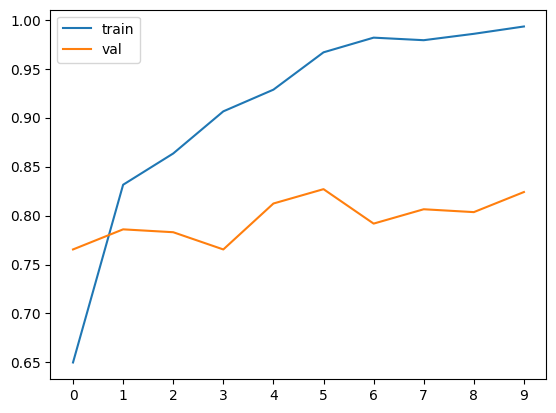

In [64]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.xticks(np.arange(10))
plt.legend()
plt.show()

### Adjusting the learning rate

In [65]:
def make_model(learning_rate=0.01):
	base_model = Xception(
			weights='imagenet',
			include_top=False,
			input_shape=(150, 150, 3)
	)

	base_model.trainable = False

	#########################################

	inputs = keras.Input(shape=(150, 150, 3))
	base = base_model(inputs, training=False)
	vectors = GlobalAvgPool2D()(base)
	outputs = Dense(10)(vectors)
	model = keras.Model(inputs, outputs)

	#########################################

	optimizer = Adam(learning_rate=learning_rate)
	loss = CategoricalCrossentropy(from_logits=True)

	model.compile(
			optimizer=optimizer,
			loss=loss,
			metrics=['accuracy']
	)

	return model

In [ ]:
scores = {}

for lr in [0.0001, 0.001, 0.01, 0.1]:
	print(lr)

	model = make_model(learning_rate=lr)
	history = model.fit(train_ds, epochs=10, validation_data=val_ds)
	scores[lr] = history.history

	print()
	print()